In [1]:
import cv2
import numpy as np
import glob
import os
import re
import pandas as pd

from lightglue import LightGlue, SuperPoint, DISK
from lightglue.utils import load_image, rbd

import matplotlib.pyplot as plt

import time

from skimage.metrics import structural_similarity as ssim

In [2]:
#Read train frames meta data
csv_path = "./sides.csv"
# read CSV
df = pd.read_csv(csv_path)

# build dictionaries for angle and direction
angle_dict = df.set_index('name')['angle'].to_dict()
direction_dict = df.set_index('name')['side'].to_dict()

print("Angle dictionary:")
print(angle_dict)

print("\nDirection dictionary:")
print(direction_dict)

Angle dictionary:
{'evertz.png': -3.097152285, 'image0.png': -18.08344538, 'image2.png': -17.98981854, 'image7.png': 4.058103803, 'image18.png': -0.9057866601, 'image22.png': -0.9821171632, 'image30.png': 7.999983472, 'image39.png': 17.91409245, 'image50.png': 3.012787504, 'image54.png': 4.106497165, 'image132.png': -3.837262117, 'image134.png': 0.0, 'image147.png': -2.305966724, 'image157.png': -6.107178112, 'image225.png': 17.83501494, 'image229.png': -4.071813894, 'image399.png': -6.009005957, 'image1521.png': 5.023039112, 'image13475.png': 18.04926877, 'image13729.png': -0.8680514497}

Direction dictionary:
{'evertz.png': 'r', 'image0.png': 'l', 'image2.png': 'l', 'image7.png': 'l', 'image18.png': 'r', 'image22.png': 'r', 'image30.png': 'r', 'image39.png': 'r', 'image50.png': 'l', 'image54.png': 'l', 'image132.png': 'r', 'image134.png': 'r', 'image147.png': 'r', 'image157.png': 'r', 'image225.png': 'r', 'image229.png': 'r', 'image399.png': 'r', 'image1521.png': 'l', 'image13475.png

In [3]:
train_folder = "HockeyHomographyTrain/train/cleaned_images"
test_folder = "HockeyHomographyTest/test/images"

In [4]:
def line_angle(x1, y1, x2, y2):
    angle_rad = np.arctan2(y2 - y1, x2 - x1)
    angle_deg = np.degrees(angle_rad)
    return angle_deg

In [5]:
test_folder = "HockeyHomographyTest/test/images"
test_paths = glob.glob(os.path.join(test_folder, "*.png"))

match_results = {}   # test_image → best_train_image

for img_path in test_paths:
    img = cv2.imread(img_path)
    if img is None:
        continue

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # yellow mask
    lower_yellow = np.array([10, 100, 100])
    upper_yellow = np.array([45, 255, 255])
    mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)

    # edges
    blur = cv2.GaussianBlur(gray, (5, 5), 1.0)
    edges = cv2.Canny(blur, 50, 150)

    kernel = np.ones((3, 3), np.uint8)
    yellow_dilated = cv2.dilate(mask_yellow, kernel, iterations=1)

    edges_near_yellow = cv2.bitwise_and(edges, yellow_dilated)

    # HoughLinesP
    lines = cv2.HoughLinesP(
        edges_near_yellow,
        rho=1,
        theta=np.pi/180,
        threshold=30,
        minLineLength=80,
        maxLineGap=20,
    )

    if lines is None:
        print("No lines detected in", os.path.basename(img_path))
        continue

    # find longest line
    longest_len = 0
    longest_line = None

    for l in lines:
        x1, y1, x2, y2 = l[0]
        length = np.hypot(x2 - x1, y2 - y1)
        if length > longest_len:
            longest_len = length
            longest_line = (x1, y1, x2, y2)

    if longest_line is None:
        continue

    # compute angle
    x1, y1, x2, y2 = longest_line
    test_angle = line_angle(x1, y1, x2, y2)

    # ----------------------------
    # Detec direction
    # If direction detected 
    # keep test and train in the same side
    # side = detect_direction(test_img)
    # ------------------------------------
    

    # ---------------------------------------------------
    # Step 3: find closest angle in train set
    # ---------------------------------------------------
    best_train = None
    best_diff = 9999

    # side = direction(test_img)    
    # presudo side----------------------------------------
    if os.path.basename(img_path) == "image422.png":
        side = "l"
    elif os.path.basename(img_path) == "image287.png":
        side = "l"
    else:
        side = None
    #---------------------------------------------------------
    
    for train_name, train_angle in angle_dict.items():
        # Todo replace by real direction function 
        # ---------------------------------------------------------
        if os.path.basename(img_path) == "image422.png":
            if side != direction_dict[train_name]:
                continue

        if os.path.basename(img_path) == "image287.png":
            if side != direction_dict[train_name]:
                continue
        # ------------------------------------------------------------
        
        diff = abs(test_angle - train_angle)
        if diff < best_diff:
            best_diff = diff
            best_train = train_name

    match_results[os.path.basename(img_path)] = (test_angle, best_train, best_diff)

# ---------------------------------------------------
# Print matching results
# ---------------------------------------------------
print("\n=== Test → Train Best Angle Matches ===\n")
for test_img, (ang, train_img, diff) in match_results.items():
    print(f"{test_img:20s}  angle={ang:7.3f}°   → match: {train_img:20s}  (diff={diff:.3f})")


=== Test → Train Best Angle Matches ===

image1080.png         angle=-18.047°   → match: image0.png            (diff=0.037)
image241.png          angle=-17.921°   → match: image2.png            (diff=0.068)
image1439.png         angle= -6.746°   → match: image157.png          (diff=0.638)
image422.png          angle= -3.972°   → match: image50.png           (diff=6.985)
image287.png          angle= -4.932°   → match: image50.png           (diff=7.945)
image293.png          angle=  0.764°   → match: image134.png          (diff=0.764)
image307.png          angle= -3.934°   → match: image132.png          (diff=0.096)
image1096.png         angle= -3.077°   → match: evertz.png            (diff=0.020)
image466.png          angle= -3.995°   → match: image229.png          (diff=0.076)
image350.png          angle=  0.966°   → match: image134.png          (diff=0.966)


In [6]:
train_folder = "HockeyHomographyTrain/train/cleaned_images"
test_folder = "HockeyHomographyTest/test/images"


max_pairs = 50

for i, (test_name, (test_angle, train_name, diff)) in enumerate(match_results.items()):
    if i >= max_pairs:
        break

    test_path = os.path.join(test_folder, test_name)
    train_path = os.path.join(train_folder, train_name)

    test_img = cv2.imread(test_path)
    train_img = cv2.imread(train_path)

    if test_img is None or train_img is None:
        print("Failed to read:", test_path, train_path)
        continue

    # convert BGR -> RGB for matplotlib
    test_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    train_rgb = cv2.cvtColor(train_img, cv2.COLOR_BGR2RGB)

    # plt.figure(figsize=(10, 4))

    # # left: test image
    # plt.subplot(1, 2, 1)
    # plt.imshow(test_rgb)
    # plt.title(f"TEST: {test_name}\nangle={test_angle:.2f}°")
    # plt.axis("off")

    # # right: matched train image
    # plt.subplot(1, 2, 2)
    # plt.imshow(train_rgb)
    # plt.title(f"TRAIN: {train_name}\nΔangle={diff:.2f}°")
    # plt.axis("off")

    # plt.tight_layout()
    # plt.show()

In [7]:
H_dict = {}
times = {}

save_folder = "warped_outputs"
os.makedirs(save_folder, exist_ok=True)

# ----------------------------
# 1. Load extractor + matcher
# ----------------------------
extractor = SuperPoint(max_num_keypoints=2048).eval().cuda()
matcher = LightGlue(features='superpoint').eval().cuda()

for i, (test_name, (test_angle, train_name, diff)) in enumerate(match_results.items()):
    if i >= max_pairs:
        break

    test_path = os.path.join(test_folder, test_name)
    train_path = os.path.join(train_folder, train_name)

    print(test_path)

    # test_img = cv2.imread(test_path)
    # train_img = cv2.imread(train_path)

    start = time.perf_counter()
    
    # ----------------------------
    # 2. Load images to GPU
    # ----------------------------
    img0 = load_image(test_path).cuda()
    img1 = load_image(train_path).cuda()
    
    # Keep CPU numpy versions for warping later
    img0_np = cv2.imread(test_path)
    img1_np = cv2.imread(train_path)
    
    # ----------------------------
    # 3. Extract features
    # ----------------------------
    feats0 = extractor.extract(img0)
    feats1 = extractor.extract(img1)
    
    # ----------------------------
    # 4. Match features
    # ----------------------------
    matches01 = matcher({'image0': feats0, 'image1': feats1})
    feats0, feats1, matches01 = [rbd(x) for x in [feats0, feats1, matches01]]
    
    matches = matches01['matches']   # shape (K,2)
    
    points0 = feats0['keypoints'][matches[:,0]].cpu().numpy()
    points1 = feats1['keypoints'][matches[:,1]].cpu().numpy()
    
    print("Matched points:", len(points0))
    
    # ----------------------------
    # 5. Find Homography (RANSAC)
    # ----------------------------
    H, mask = cv2.findHomography(points0, points1, cv2.RANSAC, 5.0)
    print("Homography:\n", H)

    H_dict[test_name] = H

    # ----------------------------
    # 6. Warp image0 to image1
    # ----------------------------
    h1, w1 = img1_np.shape[:2]
    warped = cv2.warpPerspective(img0_np, H, (w1, h1))

    end = time.perf_counter()
    times[test_path] = end - start 
    
    
    out_path = os.path.join(save_folder, f"warped_{test_name}")
    cv2.imwrite(out_path, warped)
    
    # ----------------------------
    # 7. Overlay visualization
    # ----------------------------
    # overlay = cv2.addWeighted(warped, 0.5, img1_np, 0.5, 0)
    
    # plt.figure(figsize=(14,6))
    # plt.subplot(1,3,1)
    # plt.title("Image 0 (Warped)")
    # plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    
    # plt.subplot(1,3,2)
    # plt.title("Image 1")
    # plt.imshow(cv2.cvtColor(img1_np, cv2.COLOR_BGR2RGB))
    
    # plt.subplot(1,3,3)
    # plt.title("Overlay result")
    # plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    
    # plt.show()


HockeyHomographyTest/test/images/image1080.png
Matched points: 370
Homography:
 [[ 1.04753503e+00 -7.27975804e-03 -1.74461734e+02]
 [ 7.14597980e-04  1.02310426e+00 -8.66421655e+00]
 [ 1.81603239e-05 -1.14337857e-05  1.00000000e+00]]
HockeyHomographyTest/test/images/image241.png
Matched points: 355
Homography:
 [[ 1.15541364e+00  1.08877610e-02 -4.59991370e+02]
 [ 7.48774877e-03  1.11294965e+00 -4.23089720e+01]
 [ 5.07114669e-05  2.00021243e-06  1.00000000e+00]]
HockeyHomographyTest/test/images/image1439.png
Matched points: 273
Homography:
 [[ 9.30904820e-01 -4.25441506e-02  4.82174887e+02]
 [-8.84135223e-03  9.89280028e-01  2.21405338e+01]
 [-6.11444560e-05 -1.64376098e-05  1.00000000e+00]]
HockeyHomographyTest/test/images/image422.png
Matched points: 126
Homography:
 [[ 1.04392679e+00  7.74188097e-02 -1.42080614e+03]
 [ 1.15965196e-02  1.06129588e+00  5.60596878e+01]
 [ 1.43277603e-04  9.00438491e-05  1.00000000e+00]]
HockeyHomographyTest/test/images/image287.png
Matched points: 450


In [8]:
def load_feature_points(txt_path):
  with open(txt_path, "r", encoding="utf-8") as f:
    text = f.read()

  # Clean up strange/invisible spaces (e.g., from copy-paste)
  text = text.replace("\xa0", " ").replace("\u3000", " ")
  tokens = text.split()

  if len(tokens) % 3 != 0:
    raise ValueError(
      f"Number of tokens = {len(tokens)}, which is not a multiple of 3. "
      "The file format may be incorrect."
    )

  points_dict = {}
  names = []
  pts_list = []

  i = 0
  while i < len(tokens):
    name = tokens[i]
    try:
      x = float(tokens[i + 1])
      y = float(tokens[i + 2])
    except Exception as e:
      raise ValueError(
        f"Failed to parse coordinates for {name} at token index {i}"
      ) from e

    points_dict[name] = (x, y)
    names.append(name)
    pts_list.append([x, y])

    i += 3

  pts = np.array(pts_list, dtype=np.float32)
  return points_dict, names, pts

In [9]:
def create_unified_template(path_t1, path_t2):

    # 1. Load both files
    dict_t1, names_t1, pts_t1 = load_feature_points(path_t1)
    dict_t2, names_t2, pts_t2 = load_feature_points(path_t2)

    # 2. Define STRONG Anchor Points
    # These are the points we trust 100% to define the structure.
    anchor_names = [
        "top_left_corner",
        "top_right_corner",
        "bottom_left_corner",
        "bottom_right_corner",
        "center_red_line"
    ]

    src_anchors = [] # From Template 2 (Perspective)
    dst_anchors = [] # From Template 1 (Flat)

    for name in anchor_names:
        if name in dict_t2 and name in dict_t1:
            src_anchors.append(dict_t2[name])
            dst_anchors.append(dict_t1[name])
            print(f" - {name}")
        else:
            print(f"Warning: Anchor '{name}' not found in both files.")

    pts1 = np.array(dst_anchors, dtype=np.float32) # Destination (Flat)
    pts2 = np.array(src_anchors, dtype=np.float32) # Source (Perspective)

    # 3. Calculate Static Homography using ONLY Anchors
    H_static, status = cv2.findHomography(pts2, pts1, method=0)

    # 4. Create the Unified Dictionary
    unified_dict = dict_t1.copy()

    # 5. Transform the UNIQUE points from T2 -> T1
    for name, coord in dict_t2.items():
        if name not in unified_dict:
            # Reshape for transform
            original_pt = np.array([[[coord[0], coord[1]]]], dtype=np.float32)
            transformed_pt = cv2.perspectiveTransform(original_pt, H_static)

            unified_dict[name] = (transformed_pt[0][0][0], transformed_pt[0][0][1])

    return unified_dict

In [10]:
birdseye_path = "HockeyHomographyTrain/template/birdseye_template.png"
path_perspective = "HockeyHomographyTrain/template/template4.png"

path_txt_birdseye = "HockeyHomographyTrain/template/birdseye_template_points.txt"
path_txt_perspective = "HockeyHomographyTrain/template/template4_points.txt"

points_dict1, names1, pts1 = load_feature_points(path_txt_birdseye)
points_dict2, names2, pts2 = load_feature_points(path_txt_perspective)
unified_dict = create_unified_template(path_txt_birdseye, path_txt_perspective)

 - top_left_corner
 - top_right_corner
 - bottom_left_corner
 - bottom_right_corner
 - center_red_line


In [11]:
def warp_train_images(train_path, birdseye_path, unified_dict, vis=False):
    train_images_path = train_path + "/cleaned_images"
    train_txt_path = train_path + "/points"

    H_dict = {}
        
    warped_images_list = []
    for f in os.listdir(train_images_path):
        # if (not f.endswith(".png")) or (f == "image229.png"):
        #     continue

        

        image_path = os.path.join(train_images_path, f)
        txt_path = os.path.join(train_txt_path, f.replace(".png", ".txt"))

        points_dict, names, pts = load_feature_points(txt_path)

        src_pts = [points_dict[name] for name in points_dict.keys() if name in unified_dict.keys()]
        dst_pts = [unified_dict[name] for name in points_dict.keys() if name in unified_dict.keys()]

        src_pts = np.array(src_pts, dtype=np.float32)
        dst_pts = np.array(dst_pts, dtype=np.float32)

        H, mask = cv2.findHomography(src_pts, dst_pts, method=0)

        img1 = cv2.imread(image_path)
        img2 = cv2.imread(birdseye_path)

        h, w = img2.shape[:2]

        H_dict[os.path.basename(image_path)] = H
        print(os.path.basename(image_path))

        # Apply Perspective Transform
        warped_img = cv2.warpPerspective(img1, H, (w, h), flags=cv2.INTER_LANCZOS4)
        warped_images_list.append(warped_img)

        # Visualization
        if vis:
            plt.figure(figsize=(12, 6))

            plt.subplot(121)
            plt.title("Destination Image (Ground Truth)")
            plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))

            plt.subplot(122)
            plt.title("Source Image Warped to Match Destination")
            plt.imshow(cv2.cvtColor(warped_img, cv2.COLOR_BGR2RGB))

            blended = cv2.addWeighted(img2, 0.5, warped_img, 0.5, 0)
            blended_rgb = cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(10, 10))
            plt.imshow(blended_rgb)
            plt.title(f"Overlay Check, image {f}")
            plt.show()

    print(f"{len(warped_images_list)} images from the training set were warped.")

    return warped_images_list, H_dict


In [12]:
train_path = "HockeyHomographyTrain/train"
# test_path = "/content/drive/MyDrive/Homography Project/HockeyHomographyTest/test"
birdseye_path = "HockeyHomographyTrain/template/birdseye_template.png"

warped_images_list, train_h_dict = warp_train_images(train_path,
                                       birdseye_path,
                                       unified_dict,
                                       vis=False)

image7.png
image13475.png
image2.png
image18.png
image13729.png
evertz.png
image22.png
image50.png
image147.png
image54.png
image399.png
image134.png
image0.png
image157.png
image229.png
image39.png
image225.png
image140.png
image30.png
image1521.png
image132.png
21 images from the training set were warped.


In [13]:
# bird eye trian H
print(train_h_dict)

{'image7.png': array([[ 3.94071649e-01,  1.04737064e+00, -4.10755166e+02],
       [-1.46690504e-01,  1.81122104e+00, -6.23741482e+02],
       [-4.37760932e-05,  2.01160558e-03,  1.00000000e+00]]), 'image13475.png': array([[ 1.77084592e-01,  5.32278204e-01,  9.90032987e+02],
       [ 1.32836847e-01,  1.03385236e+00, -3.58352050e+02],
       [-3.55120423e-05,  1.11827012e-03,  1.00000000e+00]]), 'image2.png': array([[ 1.82992857e-01,  5.35824062e-01, -3.49083403e+02],
       [-1.20060168e-01,  9.09391236e-01, -7.50626924e+01],
       [ 2.61334512e-05,  9.65696169e-04,  1.00000000e+00]]), 'image18.png': array([[ 3.32468618e-01,  7.89524083e-01,  2.57838517e+02],
       [ 1.46167593e-02,  1.48930600e+00, -4.91520126e+02],
       [-3.30212299e-05,  1.56244319e-03,  1.00000000e+00]]), 'image13729.png': array([[ 3.15946413e-01,  7.07019357e-01,  3.33813932e+02],
       [ 2.31966700e-02,  1.30879933e+00, -5.54574962e+02],
       [ 1.31905285e-05,  1.39929614e-03,  1.00000000e+00]]), 'evertz.pn

In [14]:
test_folder = "HockeyHomographyTest/test/images/"

test_to_bird_match = {}

for test_img, (ang, train_img, diff) in match_results.items():

    print(f"{test_img:20s}  angle={ang:7.3f}°   → match: {train_img:20s}  (diff={diff:.3f})")

    # ----------------------------
    # 1. test→train H
    # ----------------------------
    H_test_to_train = H_dict.get(test_img, None)
    if H_test_to_train is None:
        print(f"[WARN] No H(test→train) for {test_img}, skip.\n")
        continue

    # ----------------------------
    # 2. train→bird-eye H
    # ----------------------------
    H_train_to_bird = train_h_dict.get(train_img, None)
    if H_train_to_bird is None:
        print(f"[WARN] No H(train→bird) for {train_img}, skip.\n")
        continue

    # ----------------------------
    # 3. test → train → bird-eye
    # ----------------------------
    H_test_to_bird = H_train_to_bird @ H_test_to_train

    # save dictionary
    test_path = os.path.join(test_folder, test_img)
    test_to_bird_match[test_path] = H_test_to_bird

print("\n=== test→bird ===")
print(f"Total: {len(test_to_bird_match)} images")


image1080.png         angle=-18.047°   → match: image0.png            (diff=0.037)
image241.png          angle=-17.921°   → match: image2.png            (diff=0.068)
image1439.png         angle= -6.746°   → match: image157.png          (diff=0.638)
image422.png          angle= -3.972°   → match: image50.png           (diff=6.985)
image287.png          angle= -4.932°   → match: image50.png           (diff=7.945)
image293.png          angle=  0.764°   → match: image134.png          (diff=0.764)
image307.png          angle= -3.934°   → match: image132.png          (diff=0.096)
image1096.png         angle= -3.077°   → match: evertz.png            (diff=0.020)
image466.png          angle= -3.995°   → match: image229.png          (diff=0.076)
image350.png          angle=  0.966°   → match: image134.png          (diff=0.966)

=== test→bird ===
Total: 10 images


In [15]:
test_folder = "HockeyHomographyTest/test/images/"
output_folder = "HockeyHomographyTest/test/birdeye_output/"

os.makedirs(output_folder, exist_ok=True)
test_to_bird_H = {}
for test_img, (ang, train_img, diff) in match_results.items():

    test_path = os.path.join(test_folder, test_img)

    print(f"[PROCESS] {test_img:20s}  →  train={train_img:20s}")

    # ----------------------------
    # 1. test → train
    # ----------------------------
    H_test_to_train = H_dict.get(test_img)
    if H_test_to_train is None:
        print(f"[SKIP] No H_test_to_train for {test_img}\n")
        continue

    # ----------------------------
    # 2. train → bird-eye
    # ----------------------------
    H_train_to_bird = train_h_dict.get(train_img)
    if H_train_to_bird is None:
        print(f"[SKIP] No H_train_to_bird for {train_img}\n")
        continue

    # ----------------------------
    # 3. Combined Homography
    # ----------------------------
    H_test_to_bird = H_train_to_bird @ H_test_to_train

    img_path = os.path.join("HockeyHomographyTest/test/images/",test_img)
    test_to_bird_H[img_path] = H_test_to_bird

    # ----------------------------
    # 4. Load test image
    # ----------------------------
    img = cv2.imread(test_path)
    if img is None:
        print(f"[SKIP] Cannot load {test_path}\n")
        continue

    h, w = img.shape[:2]

    # ----------------------------
    # 5. Warp to bird-eye
    # ----------------------------
    warped = cv2.warpPerspective(img, H_test_to_bird, (w, h))

    # ----------------------------
    # 6. Save output
    # ----------------------------
    out_path = os.path.join(output_folder, test_img.replace(".png", "_bird.png"))
    cv2.imwrite(out_path, warped)

    print(f"[SAVED] → {out_path}\n")

print("=== All warped images exported ===")
print(f"Total output: {len(test_to_bird_H)}")

[PROCESS] image1080.png         →  train=image0.png          
[SAVED] → HockeyHomographyTest/test/birdeye_output/image1080_bird.png

[PROCESS] image241.png          →  train=image2.png          
[SAVED] → HockeyHomographyTest/test/birdeye_output/image241_bird.png

[PROCESS] image1439.png         →  train=image157.png        
[SAVED] → HockeyHomographyTest/test/birdeye_output/image1439_bird.png

[PROCESS] image422.png          →  train=image50.png         
[SAVED] → HockeyHomographyTest/test/birdeye_output/image422_bird.png

[PROCESS] image287.png          →  train=image50.png         
[SAVED] → HockeyHomographyTest/test/birdeye_output/image287_bird.png

[PROCESS] image293.png          →  train=image134.png        
[SAVED] → HockeyHomographyTest/test/birdeye_output/image293_bird.png

[PROCESS] image307.png          →  train=image132.png        
[SAVED] → HockeyHomographyTest/test/birdeye_output/image307_bird.png

[PROCESS] image1096.png         →  train=evertz.png          
[SAVED] → Ho

In [16]:
###################
### Evaluation
#######

(-0.5, 1023.5, 447.5, -0.5)

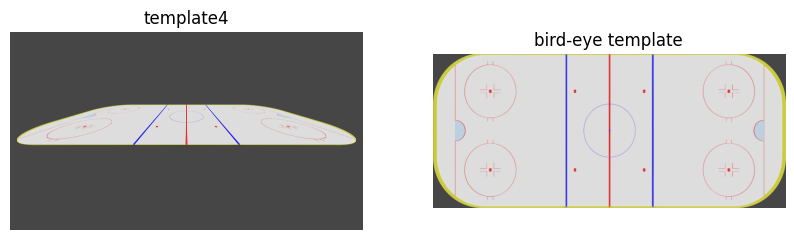

In [17]:
template_img = cv2.imread("HockeyHomographyTrain/template/template4.png")
template_img = cv2.cvtColor(template_img, cv2.COLOR_BGR2RGB)

bird_img = cv2.imread("HockeyHomographyTrain/template/birdseye_template.png")
bird_img = cv2.cvtColor(bird_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.imshow(template_img)
plt.title("template4")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(bird_img)
plt.title("bird-eye template")
plt.axis("off")

In [18]:
def load_points_txt(path):
    pts = {}
    with open(path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            name, x, y = line.split()
            pts[name] = (float(x), float(y))
    return pts


template_pts = load_points_txt("HockeyHomographyTrain/template/template4_points.txt")
bird_pts     = load_points_txt("HockeyHomographyTrain/template/birdseye_template_points.txt")

print("template points:", len(template_pts))
print("bird-eye points:", len(bird_pts))

template points: 101
bird-eye points: 21


In [19]:
common_keys = sorted(set(template_pts.keys()) & set(bird_pts.keys()))

In [20]:
src_pts = np.array(
    [template_pts[k] for k in common_keys],
    dtype=np.float32
)

dst_pts = np.array(
    [bird_pts[k] for k in common_keys],
    dtype=np.float32
)

In [21]:
H, mask = cv2.findHomography(
    src_pts,
    dst_pts,
    method=cv2.RANSAC,
    ransacReprojThreshold=5.0
)

(-0.5, 1023.5, 447.5, -0.5)

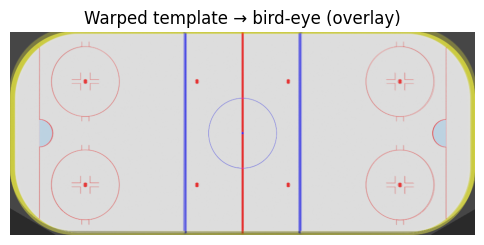

In [22]:
h, w, _ = bird_img.shape

warped = cv2.warpPerspective(
    template_img,
    H,
    (w, h)
)

overlay = cv2.addWeighted(bird_img, 0.6, warped, 0.4, 0)

plt.figure(figsize=(6,4))
plt.imshow(overlay)
plt.title("Warped template → bird-eye (overlay)")
plt.axis("off")

In [23]:
test_img_dir   = "HockeyHomographyTest/test/images"
test_pts_dir   = "HockeyHomographyTest/test/points"



In [24]:
image_files = sorted([
    f for f in os.listdir(test_img_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

print("Test images:", len(image_files))

Test images: 10


In [25]:
def warp_to_birdeye(img, H, bird_shape):
    h, w = bird_shape[:2]
    return cv2.warpPerspective(img, H, (w, h))

In [26]:
def pixel_error(img1, img2, mask=None):
    diff = img1.astype(np.float32) - img2.astype(np.float32)
    if mask is not None:
        diff = diff[mask]
    l1 = np.mean(np.abs(diff))
    l2 = np.sqrt(np.mean(diff**2))
    return l1, l2

In [27]:
def ssim_score(img1, img2, mask=None):
    g1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

    if mask is not None:
        return ssim(g1, g2, data_range=255)
    else:
        return ssim(g1, g2, data_range=255)

In [28]:
def valid_warp_mask(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return gray > 0

In [29]:
H_test_GD = {}

for img_name in image_files:

    print(f"\nProcessing {img_name}")

    img_path = os.path.join(test_img_dir, img_name)
    pts_path = os.path.join(
        test_pts_dir,
        os.path.splitext(img_name)[0] + ".txt"
    )

    

    if not os.path.exists(pts_path):
        print("  points file missing, skip")
        continue

    # --- load image ---
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- load test points ---
    test_pts = load_points_txt(pts_path)

    # --- find common points ---
    common_keys = sorted(
        set(test_pts.keys()) & set(template_pts.keys())
    )

    if len(common_keys) < 4:
        print("  not enough correspondences, skip")
        continue

    src_pts = np.array(
        [test_pts[k] for k in common_keys],
        dtype=np.float32
    )

    mid_pts = np.array(
        [template_pts[k] for k in common_keys],
        dtype=np.float32
    )

    # --- H: test -> template4 ---
    H_test_to_template, mask = cv2.findHomography(
        src_pts,
        mid_pts,
        cv2.RANSAC,
        5.0
    )

    if H_test_to_template is None:
        print("  homography failed")
        continue

    # --- compose H: test -> bird-eye ---
    H_test_to_be = H @ H_test_to_template

    # --- warp ---
    h_be, w_be, _ = bird_img.shape
    warped = cv2.warpPerspective(
        img,
        H_test_to_be,
        (w_be, h_be)
    )

    overlay = cv2.addWeighted(
        bird_img, 0.6,
        warped,   0.4,
        0
    )

    H_test_GD[img_path] = H_test_to_be



Processing image1080.png

Processing image1096.png

Processing image1439.png

Processing image241.png

Processing image287.png

Processing image293.png

Processing image307.png

Processing image350.png

Processing image422.png

Processing image466.png


In [30]:
results = []

for img_path in H_test_GD.keys():

    
    
    if img_path not in test_to_bird_H:
        continue

    # if img_path == "HockeyHomographyTest/test/images/image1096.png":
    #     continue

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # warp
    warp_gt   = warp_to_birdeye(img, H_test_GD[img_path], bird_img.shape)
    warp_pred = warp_to_birdeye(img, test_to_bird_H[img_path], bird_img.shape)

    # valid region
    mask = valid_warp_mask(warp_gt) & valid_warp_mask(warp_pred)

    # metrics
    l1, l2 = pixel_error(warp_gt, warp_pred, mask)
    s      = ssim_score(warp_gt, warp_pred)

    results.append({
        "image": img_path,
        "L1": l1,
        "L2": l2,
        "SSIM": s
    })

print("Evaluated images:", len(results))

Evaluated images: 10


In [31]:
def project_points(pts, H):
    """
    pts: (N,2)
    H:   (3,3)
    """
    pts = np.asarray(pts, dtype=np.float64)

    pts_h = np.hstack([
        pts,
        np.ones((pts.shape[0], 1))
    ])  # (N,3)

    proj = (H @ pts_h.T).T
    proj = proj[:, :2] / proj[:, 2:3]

    return proj

In [32]:
def reprojection_error_between_H(pts, H_gt, H_pred):
    """
    pts: (N,2) test image points
    """
    proj_gt   = project_points(pts, H_gt)
    proj_pred = project_points(pts, H_pred)

    errors = np.linalg.norm(proj_gt - proj_pred, axis=1)
    return errors

In [33]:
all_errors = []
each_errors = {}

for img_path in H_test_GD.keys():

    
    if img_path not in test_to_bird_H:
        continue
    
    # An annotation error was found in test image 1096, where the top_left_vertical_line and top_right_vertical_line were reversed
    ### Have already fixed 
    # if img_path == "HockeyHomographyTest/test/images/image1096.png":
    #     continue

    pts_path = os.path.join(
        "HockeyHomographyTest/test/points",
        os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    )

    if not os.path.exists(pts_path):
        continue

    test_pts_dict = load_points_txt(pts_path)
    test_pts = np.array(list(test_pts_dict.values()), dtype=np.float64)

    errs = reprojection_error_between_H(
        test_pts,
        H_test_GD[img_path],
        test_to_bird_H[img_path]
    )

    each_errors[img_path] = errs
    all_errors.extend(errs)

In [34]:
all_errors = np.array(all_errors)

print("Reprojection error (px)")
print("Mean  :", all_errors.mean())
print("Median:", np.median(all_errors))
print("Std   :", all_errors.std())
print("Max   :", all_errors.max())

Reprojection error (px)
Mean  : 4.439002018297752
Median: 2.0760955500652734
Std   : 12.29939106081496
Max   : 132.21264600263916


In [35]:
for img_path in each_errors.keys():
    print(img_path)
    print("Reprojection error (px)")
    print("Mean  :", each_errors[img_path].mean())
    print("Median:", np.median(each_errors[img_path]))
    print("Std   :", each_errors[img_path].std())
    print("Max   :", each_errors[img_path].max())

HockeyHomographyTest/test/images/image1080.png
Reprojection error (px)
Mean  : 1.3459810946896222
Median: 1.4575465260079499
Std   : 0.3953117757434171
Max   : 1.9120293230102512
HockeyHomographyTest/test/images/image1096.png
Reprojection error (px)
Mean  : 1.9855021180905208
Median: 1.6856075517082902
Std   : 1.1295299133621077
Max   : 4.6477974223919345
HockeyHomographyTest/test/images/image1439.png
Reprojection error (px)
Mean  : 1.8481463342368223
Median: 1.6963228278139861
Std   : 1.4403783429945232
Max   : 5.622738598590279
HockeyHomographyTest/test/images/image241.png
Reprojection error (px)
Mean  : 3.1290620498282933
Median: 3.385455327421936
Std   : 0.6075294908677581
Max   : 3.9110730083896583
HockeyHomographyTest/test/images/image287.png
Reprojection error (px)
Mean  : 5.81492568761252
Median: 4.057903849670347
Std   : 4.788949553876196
Max   : 23.331755158161968
HockeyHomographyTest/test/images/image293.png
Reprojection error (px)
Mean  : 1.8292921265556126
Median: 1.473182

In [36]:
for img in times.keys():
    print(img + ": " + str(times[img]))

HockeyHomographyTest/test/images/image1080.png: 0.6585185160001856
HockeyHomographyTest/test/images/image241.png: 0.1928512119993684
HockeyHomographyTest/test/images/image1439.png: 0.16974007400131086
HockeyHomographyTest/test/images/image422.png: 0.1568910230016627
HockeyHomographyTest/test/images/image287.png: 0.15371515200240538
HockeyHomographyTest/test/images/image293.png: 0.1548181559992372
HockeyHomographyTest/test/images/image307.png: 0.1591330340015702
HockeyHomographyTest/test/images/image1096.png: 0.155767136002396
HockeyHomographyTest/test/images/image466.png: 0.14844080799957737
HockeyHomographyTest/test/images/image350.png: 0.15709951399912825
